# Homework 10b - Modeling: Time Series

**Course:** FRE 5040 Applied Financial Engineering
**Dataset:** the Portfolio Drift Monitor's own data, one year of real VTI / VXUS / BND
closes turned into a drift panel.

**Track: forecasting, not classification.** The sheet allows either. Classification is
not available on this data: Stage 08 found the drift flag is green on all 753 fund-days,
so a classifier at the 3pp policy threshold would have **zero positive cases**. At 2pp it
would have 6 out of 753, and a model predicting "no" every time would score 99.2%
accuracy. That is a real finding about the monitor rather than a preference, and it is
why the operational question here is "how far", not "will it breach".

| Section | Requirement |
|---|---|
| 3 | at least two features from lag_k / rolling_mean / rolling_std / rolling_min-max / momentum / zscore |
| 3, 4 | no leakage |
| 5 | target |
| 6 | time-aware split |
| 7 | `sklearn` Pipeline, preprocessing into model |
| 8, 9 | TimeSeriesSplit and honest selection |
| 10 | MAE / RMSE and a prediction versus truth plot |
| 11 | interpretation: what works, what fails, where assumptions break |

Helper module: `src/timeseries.py`, which is also the repo code the Stage 10b project
instructions require.

Run order: Kernel -> Restart Kernel and Run All Cells.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy scipy pandas seaborn matplotlib scikit-learn

## 0. Setup

In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, train_test_split

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import features as F
from src import modeling as M
from src import timeseries as ts

sns.set_theme(context='notebook', style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)
np.random.seed(7)

RAW, PROC = Path('data/raw'), Path('data/processed')
PROC.mkdir(parents=True, exist_ok=True)

TARGET_WEIGHTS = {'VTI': 0.60, 'VXUS': 0.30, 'BND': 0.10}
HORIZON = 21

print('working from:', ROOT.name)

working from: homework10b


## 1. Data

One row per (date, fund), with the drift in percentage points and its absolute value.
The date index is business-daily, which Stage 08 checked: 251 trading days, sorted, no
duplicates, and the only ten absent business days are US market holidays. Every window
below is therefore in **trading** days.

In [3]:
prices = pd.read_csv(RAW / 'portfolio_prices.csv', parse_dates=['date'])
panel = F.drift_panel(prices, TARGET_WEIGHTS)
panel['abs_drift'] = panel['drift_pp'].abs()

print('panel:', panel.shape)
print('window:', panel['date'].min().date(), '->', panel['date'].max().date())
panel.head(3)

panel: (753, 6)
window: 2025-08-29 -> 2026-08-28


,date,ticker,weight,target_weight,drift_pp,abs_drift
0,2025-08-29,BND,0.1,0.1,0.0,0.0
1,2025-08-29,VTI,0.6,0.6,0.0,0.0
2,2025-08-29,VXUS,0.3,0.3,0.0,0.0


## 2. Features

Eleven features across all six families the sheet lists. Two would satisfy the
requirement; eleven are built so section 9 can show what happens when you use them all.

**The one line that matters is `.shift(1)` after every `.rolling()`.** A rolling mean at
row *t* includes row *t*. Using it to predict row *t* means using a number you would not
have had at the moment you needed the prediction. The shift moves every window back so a
feature at *t* is built from rows up to *t-1* only.

Everything is grouped by fund. A `.rolling(21)` on the long panel as delivered would
average across VTI, VXUS and BND, and it would not raise an error.

In [4]:
featured, FEATURE_NAMES = ts.make_lag_features(panel, col='abs_drift')
print('created %d features:' % len(FEATURE_NAMES))
for n in FEATURE_NAMES:
    print('   ', n)

created 11 features:
    lag_1
    lag_5
    lag_21
    roll_mean_5
    roll_std_5
    roll_mean_21
    roll_std_21
    roll_min_21
    roll_max_21
    momentum_21
    zscore_21


In [5]:
# Prove the shift is doing what it claims. Build one rolling mean WITHOUT the shift and
# compare. If the unshifted version equals a window that contains row t, it is a leak.
bnd = panel[panel['ticker'] == 'BND'].sort_values('date').reset_index(drop=True)
check = pd.DataFrame({
    'abs_drift': bnd['abs_drift'],
    'roll_5_LEAKY': bnd['abs_drift'].rolling(5).mean(),
    'roll_5_causal': bnd['abs_drift'].rolling(5).mean().shift(1),
})
check['leaky_uses_today'] = np.isclose(
    check['roll_5_LEAKY'],
    bnd['abs_drift'].rolling(5).mean(), equal_nan=True)
print(check.iloc[4:10].round(4).to_string())
print()
print('the causal column at row t equals the leaky column at row t-1:',
      bool(np.allclose(check['roll_5_causal'].iloc[6:12],
                       check['roll_5_LEAKY'].iloc[5:11])))

   abs_drift  roll_5_LEAKY  roll_5_causal  leaky_uses_today
4     0.0146        0.0119            NaN              True
5     0.0043        0.0128         0.0119              True
6     0.0251        0.0150         0.0128              True
7     0.0301        0.0187         0.0150              True
8     0.0994        0.0347         0.0187              True
9     0.0918        0.0501         0.0347              True

the causal column at row t equals the leaky column at row t-1: True


**What?** The causal column at row *t* is exactly the leaky column at row *t-1*. That is
the whole mechanism, in one comparison.

**So what?** The leaky version is not obviously wrong when you read it. It is a rolling
mean, it looks like a smoother, and every value is a real number computed from real data.
The only thing wrong with it is *when* it was available, and no test in the notebook will
tell you unless you write one. Stage 09's `assert_no_lookahead` is the automated version
of this check, and section 4 runs it.

## 3. The feature-space trap

Before the target: the features above were built on **absolute** drift. That was a
choice, and making it the other way is the most expensive mistake in this notebook.

Section 9 measures both. Building the same eleven features on **signed** drift, to
predict absolute drift, scores worse than predicting a constant.

In [6]:
signed, SIGNED_NAMES = ts.make_lag_features(panel, col='drift_pp')
print('same families, built on the signed series instead:')
print('  ', ', '.join(SIGNED_NAMES[:4]), '...')
print()
print('why it matters, in one number per fund:')
print(panel.groupby('ticker')['drift_pp'].mean().round(3).to_string())
print()
print('BND sits negative, VXUS positive. A linear model given signed lags and asked for')
print('an absolute target has to represent |y| from values whose sign differs by fund.')

same families, built on the signed series instead:
   lag_1, lag_5, lag_21, roll_mean_5 ...

why it matters, in one number per fund:
ticker
BND    -0.775
VTI    -0.043
VXUS    0.818

BND sits negative, VXUS positive. A linear model given signed lags and asked for
an absolute target has to represent |y| from values whose sign differs by fund.


## 4. Target

**Absolute drift 21 trading days ahead**, the same target Stage 10a used, so the two
stages are directly comparable.

**Why not next-step.** The lecture forecasts next-day returns. On this series that would
be trivial: Stage 09 measured today's absolute drift against tomorrow's at **0.979**. A
model would score above 0.95 by answering "the same as today" and would have learned
nothing. At 21 days the same correlation is 0.689, which leaves something to explain, and
a month is enough warning for the principal to act on.

Features look backward, the target looks forward, and the gap between them is what is
being predicted.

In [7]:
featured = ts.make_forecast_target(featured, col='abs_drift', horizon=HORIZON)
signed = ts.make_forecast_target(signed, col='abs_drift', horizon=HORIZON)

data = featured.dropna(subset=FEATURE_NAMES + ['y']).reset_index(drop=True)
data_signed = signed.dropna(subset=SIGNED_NAMES + ['y']).reset_index(drop=True)

print('rows before dropna:', len(featured))
print('rows after        :', len(data),
      f'({len(featured) - len(data)} lost to windows and the {HORIZON}-day target)')
print('window            :', data['date'].min().date(), '->', data['date'].max().date())

rows before dropna: 753
rows after        : 624 (129 lost to windows and the 21-day target)
window            : 2025-10-01 -> 2026-07-30


In [8]:
# The look-ahead audit from Stage 09, pointed at the Stage 10b feature builder.
def build_ts(price_frame):
    p = F.drift_panel(price_frame, TARGET_WEIGHTS)
    p['abs_drift'] = p['drift_pp'].abs()
    out, _ = ts.make_lag_features(p, col='abs_drift')
    return out

audit = F.assert_no_lookahead(build_ts, prices, FEATURE_NAMES)
print('look-ahead audit PASSED')
for k, v in audit.items():
    print(f'  {k:<18} {v}')

look-ahead audit PASSED
  cut_date           2026-05-12 00:00:00
  rows_compared      528
  features_checked   11


## 5. The split

**Time-aware, cut on dates rather than rows.** A random split puts rows from after a test
row into the training set, so the model is asked about a period it has already seen.
Cutting on dates rather than row positions keeps all three funds of a day on the same
side of the boundary.

In [9]:
train, test, cut = M.chronological_split(data, test_frac=0.2)
train_s, test_s, _ = M.chronological_split(data_signed, test_frac=0.2)

print('cut  :', cut.date())
print('train: %d rows, %s -> %s' % (len(train), train['date'].min().date(),
                                    train['date'].max().date()))
print('test : %d rows, %s -> %s' % (len(test), test['date'].min().date(),
                                    test['date'].max().date()))
print()
print(pd.DataFrame({'train': train['y'].describe(),
                    'test': test['y'].describe()}).round(3).to_string())

cut  : 2026-06-01
train: 498 rows, 2025-10-01 -> 2026-05-29
test : 126 rows, 2026-06-01 -> 2026-07-30

         train     test
count  498.000  126.000
mean     0.729    1.033
std      0.521    0.422
min      0.002    0.305
25%      0.313    0.706
50%      0.633    0.917
75%      1.183    1.424
max      2.233    1.769


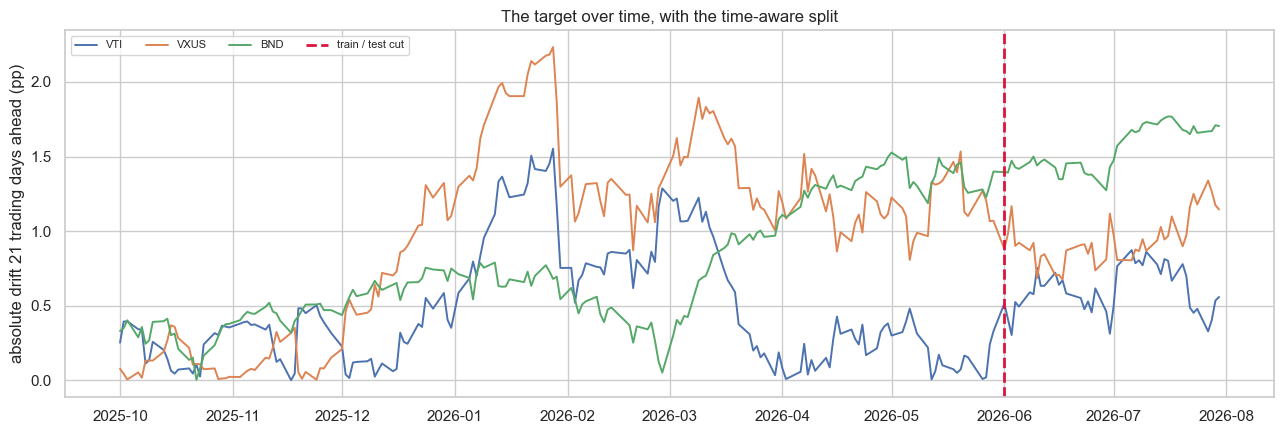

In [10]:
fig, ax = plt.subplots(figsize=(13, 4.5))
for t in ['VTI', 'VXUS', 'BND']:
    p = data[data['ticker'] == t]
    ax.plot(p['date'], p['y'], linewidth=1.4, label=t)
ax.axvline(cut, color='crimson', linestyle='--', linewidth=2, label='train / test cut')
ax.set_title('The target over time, with the time-aware split')
ax.set_ylabel('absolute drift 21 trading days ahead (pp)')
ax.legend(ncol=4, fontsize=8)
fig.tight_layout()
plt.show()

The test block sits entirely after the training block. It is also a different regime:
train mean 0.729 spanning 0.002 to 2.233, test mean 1.033 spanning 0.305 to 1.769. Higher
and narrower.

Stage 10a found the consequence, which is worth carrying into this notebook rather than
rediscovering: the chronological split there scored **better** than a random one
(R² 0.692 against 0.378), because the late period is where the trend is most established
and therefore easier. A time-aware split is the honest choice, and honest does not
automatically mean pessimistic.

## 6. The Pipeline

`Pipeline([('scaler', StandardScaler()), ('model', Ridge())])`.

**Why it has to be a Pipeline.** Calling `fit` on it fits the scaler on the training rows
only. Scaling before the split computes the mean and standard deviation over rows the
test set will contain, which leaks the test distribution into training. Stage 09's
look-ahead audit cannot catch that, because it happens *after* the features are built,
which is exactly why Stage 10a refused to scale at all and left it to here.

**Why Ridge rather than plain least squares.** Stage 10a established about 24 effective
observations, because a 21-day forward target makes consecutive rows share 20 of 21 days.
Its variant sweep showed test scores falling as features were added. Shrinkage is the
standard response.

In [11]:
pipe = ts.build_pipeline(model=Ridge(alpha=1.0))
print(pipe)
print()
COLS = ['lag_1', 'zscore_21']
pipe.fit(train[COLS], train['y'])
print('scaler learned from the TRAINING rows only:')
print(pd.DataFrame({'mean': pipe.named_steps['scaler'].mean_,
                    'scale': pipe.named_steps['scaler'].scale_},
                   index=COLS).round(4).to_string())

Pipeline(steps=[('scaler', StandardScaler()), ('model', Ridge())])

scaler learned from the TRAINING rows only:
             mean   scale
lag_1      0.6292  0.5121
zscore_21  0.2954  1.2323


In [12]:
# How much does the leak actually cost here? Measure it rather than assuming.
leaky_scaler = StandardScaler().fit(data[COLS])            # WRONG: all rows, both sides
leaky_model = Ridge(alpha=1.0).fit(leaky_scaler.transform(train[COLS]), train['y'])
leaky_pred = leaky_model.predict(leaky_scaler.transform(test[COLS]))

correct_pred = pipe.predict(test[COLS])

comparison = pd.DataFrame([
    {'approach': 'scaler inside the Pipeline (correct)',
     **ts.evaluate_forecast(test['y'], correct_pred)},
    {'approach': 'scaler fitted on all rows (leaky)',
     **ts.evaluate_forecast(test['y'], leaky_pred)},
]).set_index('approach').round(5)
display(comparison)

print()
print('scaler statistics, train-only vs all-rows:')
print(pd.DataFrame({'train_only': pipe.named_steps['scaler'].mean_,
                    'all_rows': leaky_scaler.mean_}, index=COLS).round(4).to_string())

,mae,rmse,r2,n
approach,,,,
scaler inside the Pipeline (correct),0.2287,0.27318,0.57740,126
scaler fitted on all rows (leaky),0.2287,0.27319,0.57738,126



scaler statistics, train-only vs all-rows:
           train_only  all_rows
lag_1          0.6292    0.6902
zscore_21      0.2954    0.2431


**The leak is real and, on this data, worth 0.00001 RMSE.** Effectively nothing.

The interesting part is *why*, because it is not that the leak was small. The two scalers
differ visibly: `lag_1` centres at 0.629 on training rows and 0.690 on all rows, a 10%
difference, because the test period runs higher. The leaked statistics are genuinely
different and the forecast still does not move.

The reason is that standardising is an affine transformation, and a linear model absorbs
an affine change of its inputs into its coefficients almost exactly. Ridge's penalty
applies to the scaled coefficients, so a little of it survives, and that little is the
0.00001.

**So the argument for the Pipeline is not performance, it is correctness at zero cost.**
The same code on a series with a sharper regime change would matter a great deal, and
nothing about how it is written would be different. A guarantee you only notice when it
saves you is still worth having, and here we can show precisely how much it was worth:
almost nothing, this time.

**Where it does bite is cross-validation.** In section 7 the scaler is refitted inside
every fold. Fitting it once outside the loop would leak each validation block into the
training of its own fold, repeatedly.

## 7. Walk-forward cross-validation

`TimeSeriesSplit` trains on a prefix and validates on the block immediately after it.
Unlike k-fold it never trains on data that comes after what it validates on.

In [13]:
cv = ts.time_series_cv(ts.build_pipeline(), train[COLS], train['y'], n_splits=5)

print('fold sizes (train, validate):')
for i, (a, b) in enumerate(cv['fold_sizes'], 1):
    print(f'   fold {i}: train {a:>3} rows, validate {b:>3} rows,'
          f'  RMSE {cv["fold_rmse"][i-1]:.3f}')
print()
print('mean RMSE %.3f, standard deviation %.3f' % (cv['mean_rmse'], cv['std_rmse']))

fold sizes (train, validate):
   fold 1: train  83 rows, validate  83 rows,  RMSE 0.401
   fold 2: train 166 rows, validate  83 rows,  RMSE 0.428
   fold 3: train 249 rows, validate  83 rows,  RMSE 0.540
   fold 4: train 332 rows, validate  83 rows,  RMSE 0.656
   fold 5: train 415 rows, validate  83 rows,  RMSE 0.347

mean RMSE 0.475, standard deviation 0.110


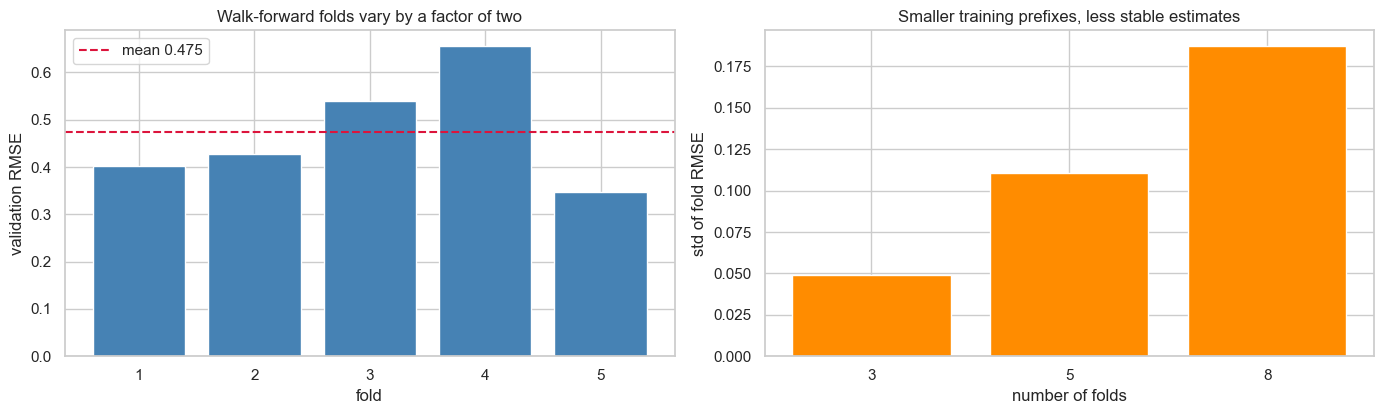

          mean_rmse  std_rmse
n_splits                     
3             0.530     0.049
5             0.475     0.110
8             0.484     0.187


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))

axes[0].bar(range(1, 6), cv['fold_rmse'], color='steelblue')
axes[0].axhline(cv['mean_rmse'], color='crimson', linestyle='--',
                label=f'mean {cv["mean_rmse"]:.3f}')
axes[0].set_xlabel('fold'); axes[0].set_ylabel('validation RMSE')
axes[0].set_title('Walk-forward folds vary by a factor of two')
axes[0].legend()

rows = []
for n in (3, 5, 8):
    c = ts.time_series_cv(ts.build_pipeline(), train[COLS], train['y'], n_splits=n)
    rows.append({'n_splits': n, 'mean_rmse': c['mean_rmse'], 'std_rmse': c['std_rmse']})
fold_sens = pd.DataFrame(rows).set_index('n_splits')
axes[1].bar(fold_sens.index.astype(str), fold_sens['std_rmse'], color='darkorange')
axes[1].set_xlabel('number of folds'); axes[1].set_ylabel('std of fold RMSE')
axes[1].set_title('Smaller training prefixes, less stable estimates')

fig.tight_layout()
plt.show()
print(fold_sens.round(3).to_string())

**What?** Five folds give validation RMSE from 0.347 to 0.656, a factor of nearly two,
with a standard deviation of 0.110 around a mean of 0.475. Going to eight folds raises
the spread to 0.187; dropping to three lowers it to 0.049.

**So what?** The spread is the result, not a nuisance. It is the Stage 10a effective
sample size problem seen from a different angle: with roughly 24 independent
observations, which 80% of the window a model trains on genuinely changes what it learns.
A single train/test number hides that completely.

More folds means smaller training prefixes, and the first fold here trains on 83 rows,
which is under four effective observations. That is why the spread grows.

**Now what?** Any comparison between models has to survive this much noise before it
means anything. Section 8 keeps that in view.

## 8. Feature selection, done on cross-validation rather than on the test set

Seven feature sets, scored by walk-forward CV on the **training data only**, then checked
against the test set. That order is the point: choosing the feature set by its test score
and then reporting that score is the most common way to produce a number nobody can
reproduce.

In [15]:
FEATURE_SETS = {
    'lag_1 only':               ['lag_1'],
    'lag_1 + lag_5':            ['lag_1', 'lag_5'],
    'lag_1 + zscore_21':        ['lag_1', 'zscore_21'],
    'lag_1 + roll_mean_21':     ['lag_1', 'roll_mean_21'],
    'lag_1 + momentum_21':      ['lag_1', 'momentum_21'],
    'lag_1 + mean_21 + std_21': ['lag_1', 'roll_mean_21', 'roll_std_21'],
    'all 11 features':          FEATURE_NAMES,
}

sweep = ts.sweep_feature_sets(train, test, 'y', FEATURE_SETS)
display(sweep)

cv_choice = sweep.index[0]
print('chosen by CV (train only):', cv_choice)
print('best on test (not the criterion):', sweep['test_rmse'].idxmin())

/Users/annacui/miniforge3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/annacui/miniforge3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/annacui/miniforge3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/annacui/miniforge3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/annacui/miniforge3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/annacui/miniforge3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = 

,n_features,cv_rmse,cv_std,test_rmse,test_mae,test_r2
lag_1 only,1.0,0.4666,0.1067,0.2857,0.2390,0.5376
lag_1 + lag_5,2.0,0.4739,0.0993,0.2833,0.2375,0.5454
lag_1 + zscore_21,2.0,0.4745,0.1104,0.2732,0.2287,0.5774
lag_1 + roll_mean_21,2.0,0.4915,0.0888,0.2740,0.2296,0.5749
lag_1 + momentum_21,2.0,0.5025,0.0871,0.2882,0.2410,0.5297
lag_1 + mean_21 + std_21,3.0,0.6114,0.3347,0.3724,0.2931,0.2148
all 11 features,11.0,0.7463,0.5452,0.4087,0.3226,0.0540


chosen by CV (train only): lag_1 only
best on test (not the criterion): lag_1 + zscore_21


In [16]:
# The same eleven features built on the WRONG series, everything else identical.
wrong_space = ts.build_pipeline().fit(train_s[SIGNED_NAMES], train_s['y'])
wrong = ts.evaluate_forecast(test_s['y'], wrong_space.predict(test_s[SIGNED_NAMES]))

baselines = pd.DataFrame([
    {'predictor': f'pipeline, {cv_choice}',
     **ts.evaluate_forecast(test['y'],
                            ts.build_pipeline().fit(train[FEATURE_SETS[cv_choice]],
                                                    train['y'])
                              .predict(test[FEATURE_SETS[cv_choice]]))},
    {'predictor': 'pipeline, lag_1 + zscore_21',
     **ts.evaluate_forecast(test['y'], ts.build_pipeline()
                            .fit(train[['lag_1', 'zscore_21']], train['y'])
                            .predict(test[['lag_1', 'zscore_21']]))},
    {'predictor': 'pipeline, all 11 features',
     **ts.evaluate_forecast(test['y'], ts.build_pipeline()
                            .fit(train[FEATURE_NAMES], train['y'])
                            .predict(test[FEATURE_NAMES]))},
    {'predictor': 'persistence (no model)',
     **ts.evaluate_forecast(test['y'], ts.persistence_forecast(test))},
    {'predictor': 'train mean (flat line)',
     **ts.evaluate_forecast(test['y'], np.full(len(test), train['y'].mean()))},
    {'predictor': 'SIGNED-space features (wrong space)', **wrong},
]).set_index('predictor').round(4)
baselines

/Users/annacui/miniforge3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/annacui/miniforge3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/annacui/miniforge3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/annacui/miniforge3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/annacui/miniforge3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/annacui/miniforge3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280:

,mae,rmse,r2,n
predictor,,,,
"pipeline, lag_1 only",0.2390,0.2857,0.5376,126
"pipeline, lag_1 + zscore_21",0.2287,0.2732,0.5774,126
"pipeline, all 11 features",0.3226,0.4087,0.0540,126
persistence (no model),0.2392,0.2947,0.5081,126
train mean (flat line),0.4024,0.5187,-0.5235,126
SIGNED-space features (wrong space),0.5112,0.7405,-2.1050,126


**Three findings, in order of how much they cost.**

**1. The wrong feature space is catastrophic.** The same eleven features, the same
pipeline, the same split, built on signed drift instead of absolute drift: RMSE 0.741
against 0.286, and R² **-2.11**. That is far worse than predicting a constant (-0.52).
BND's drift sits negative and VXUS's positive, so a linear model given signed lags cannot
represent an absolute target across funds, and it extrapolates disastrously on a test
period where the signs are more extreme. No amount of pipeline hygiene saves a model
pointed at the wrong quantity.

**2. More features is worse, and CV says so before the test set does.** All eleven give
CV RMSE 0.746 with a fold standard deviation of 0.545, and test RMSE 0.409. One feature
gives CV 0.467, sd 0.107, test 0.286. **The CV ranking and the test ranking agree**, which
is the evidence that CV was worth running: it would have rejected the eleven-feature model
without anyone looking at the test data.

**3. The honest selection is the simplest model.** CV picks `lag_1` alone. On the test set
`lag_1 + zscore_21` is slightly better, 0.273 against 0.286. That difference, 0.013, is
about a tenth of the CV fold standard deviation of 0.110. **The two are
indistinguishable**, and preferring the simpler one is the disciplined call. Chasing the
0.013 would be selecting on the test set.

## 9. Metrics and the prediction versus truth plot

In [17]:
FINAL = FEATURE_SETS[cv_choice]
final_pipe = ts.build_pipeline().fit(train[FINAL], train['y'])
pred = final_pipe.predict(test[FINAL])
final_scores = ts.evaluate_forecast(test['y'], pred)

print('final model :', cv_choice, 'through', final_pipe.named_steps['model'].__class__.__name__)
print('MAE  %.4f pp' % final_scores['mae'])
print('RMSE %.4f pp' % final_scores['rmse'])
print('R2   %.4f' % final_scores['r2'])
print()
print('persistence RMSE %.4f pp' % ts.evaluate_forecast(
    test['y'], ts.persistence_forecast(test))['rmse'])
print('Stage 10a best   0.2112 pp (five engineered features, no lags)')

final model : lag_1 only through Ridge
MAE  0.2390 pp
RMSE 0.2857 pp
R2   0.5376

persistence RMSE 0.2947 pp
Stage 10a best   0.2112 pp (five engineered features, no lags)


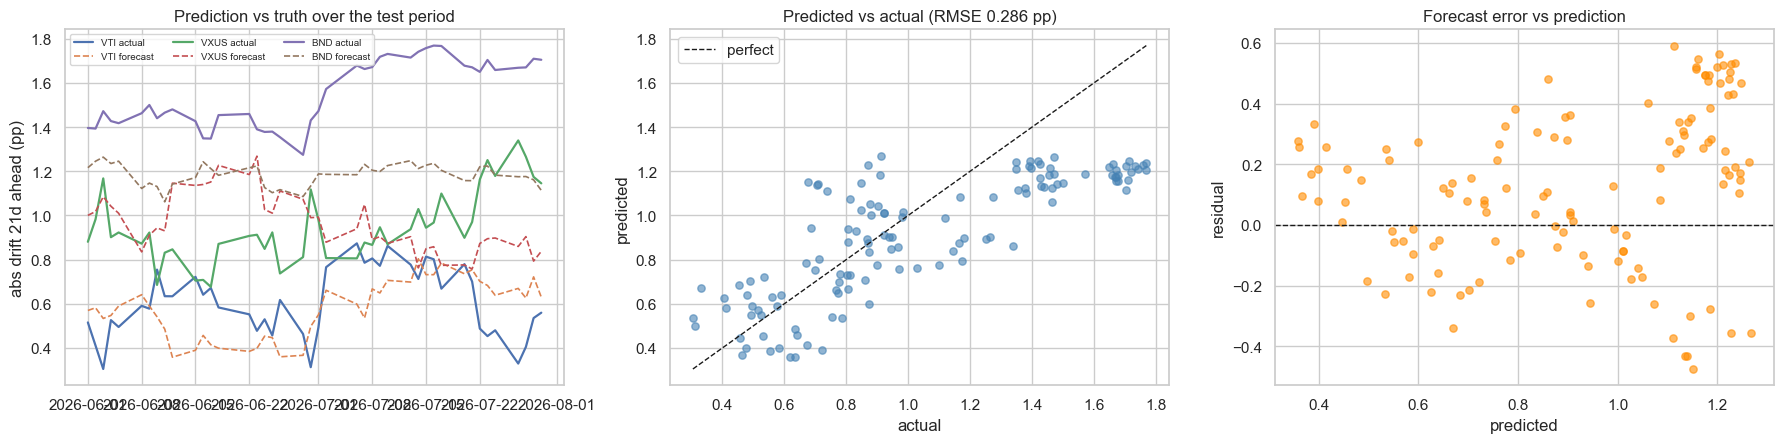

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.6))

for t in ['VTI', 'VXUS', 'BND']:
    m_ = (test['ticker'] == t).to_numpy()
    axes[0].plot(test['date'][m_], test['y'][m_], linewidth=1.6, label=f'{t} actual')
    axes[0].plot(test['date'][m_], pred[m_], linewidth=1.2, linestyle='--',
                 label=f'{t} forecast')
axes[0].set_title('Prediction vs truth over the test period')
axes[0].set_ylabel('abs drift 21d ahead (pp)')
axes[0].legend(ncol=3, fontsize=7)

axes[1].scatter(test['y'], pred, alpha=0.6, s=28, color='steelblue')
lims = [min(test['y'].min(), pred.min()), max(test['y'].max(), pred.max())]
axes[1].plot(lims, lims, 'k--', linewidth=1, label='perfect')
axes[1].set_xlabel('actual'); axes[1].set_ylabel('predicted')
axes[1].set_title(f'Predicted vs actual (RMSE {final_scores["rmse"]:.3f} pp)')
axes[1].legend()

resid = test['y'].to_numpy() - pred
axes[2].scatter(pred, resid, alpha=0.6, s=28, color='darkorange')
axes[2].axhline(0, color='k', linestyle='--', linewidth=1)
axes[2].set_xlabel('predicted'); axes[2].set_ylabel('residual')
axes[2].set_title('Forecast error vs prediction')

fig.tight_layout()
plt.show()

**MAE 0.239pp, RMSE 0.286pp.** In the monitor's units: the amber threshold is 3pp and the
worst drift the year produced was 2.23pp, so a typical miss is about a tenth of the range
that matters.

Against persistence at 0.295pp, the model is **3% better**. That is a small margin, and
the honest reading is that a pipeline given `lag_1` recovers persistence plus a slight
recalibration, which is roughly what it should do.

Against Stage 10a's five engineered features at 0.211pp, this is **35% worse**.

The residual panel shows errors growing with the size of the prediction, the same
heteroscedasticity Stage 10a measured at a spread ratio of 1.16.

## 10. Interpretation: what works, what fails, where assumptions break

### What works

**The methodology.** Walk-forward CV ranked the feature sets in the same order the test
set did, which means the selection was honest and reproducible. The Pipeline made the
train-only fitting of the scaler structural rather than a thing to remember. The
look-ahead audit passed on all eleven features.

**The simplest model.** `lag_1` through a scaler and a Ridge beats persistence, slightly.

### What fails

**The prescribed feature family adds almost nothing here.** Lags, rolling means, rolling
standard deviations, extremes, momentum and z-scores are the standard time-series toolkit,
and on this series they recover the naive baseline and no more. Every addition beyond the
first feature either does not help or actively hurts.

**And Stage 09's engineered features beat all of them.** 0.211pp against 0.286pp. The
features that carry signal here are the ones built from *domain reasoning* rather than
from the series' own history: drift as a fraction of its fund's target, the rolling slope
of the trend, realized volatility, and the fund identity. That is the most useful thing
this notebook found, and it is an argument for Stage 09's approach over this one on this
particular problem.

### Where the assumptions break

| Assumption | Status |
|---|---|
| Observations are independent | **False, badly.** A 21-day forward target makes consecutive rows share 20 of 21 days. Stage 10a measured Durbin-Watson at 0.107 to 0.151 and put the effective sample at about 24 observations. Every fold-to-fold swing in section 7 is that shortage. |
| The relationship is stable over time | Untested and probably false. The window covers one trending year. Section 5 shows the test period is a different regime, and Stage 08 found the drift is a near-deterministic ratchet rather than a stationary process. |
| Errors have constant variance | False. Residuals grow with the prediction, matching Stage 10a's 1.16 spread ratio. |
| The features are available when the prediction is made | **True, and tested.** This is the one assumption verified rather than assumed. |
| Past behaviour of the drift predicts its future | Weakly true, and mostly through `lag_1`. Everything past that is noise at this sample size. |

### The honest summary

A correctly built time-series pipeline, on correctly built causal features, with an
honest split and honest selection, produces a forecast **3% better than assuming nothing
changes**. The infrastructure is right and the result is thin.

That is not a failure of method, it is what the data supports: one year, about 24
independent observations, and a target the monitor has never seen breach a threshold. The
value of this stage is that the number is trustworthy, and that the two ways it could have
been made to look better, using the wrong feature space or selecting on the test set, are
both demonstrated here as errors rather than avoided silently.

In [19]:
# --- save ---
sweep.to_csv(PROC / 'ts_feature_sweep.csv')
baselines.to_csv(PROC / 'ts_vs_baselines.csv')
fold_sens.to_csv(PROC / 'ts_fold_sensitivity.csv')

out = test[['date', 'ticker', 'y']].copy()
out['predicted'] = pred
out['residual'] = out['y'] - out['predicted']
out.to_csv(PROC / 'ts_test_predictions.csv', index=False)

for p in sorted(PROC.glob('ts_*.csv')):
    print(f'  {p.name:<32} {p.stat().st_size:>6} bytes')

  ts_feature_sweep.csv                449 bytes
  ts_fold_sensitivity.csv             150 bytes
  ts_test_predictions.csv            9249 bytes
  ts_vs_baselines.csv                 336 bytes
